### Задание 1


Создайте систему компьютерного зрения, которая будет определять тип геометрической фигуры. Используя подготовленную базу и шаблон ноутбука проведите серию экспериментов по тестированию точности и перебору гиперпараметров нейронной сети, распознающей три категории изображений (треугольник, круг, квадрат). Используйте полносвязную архитектуру.

1. Поменяйте количество нейронов в сети, используя следующие значения:

- один слой 10 нейронов
- один слой 100 нейронов
- один слой 5000 нейронов.

2. Поменяйте активационную функцию в скрытых слоях с `relu` на `linear`.
3. Поменяйте размеры batch_size:
- 10
- 100
- 1000

4. Выведите на экран получившиеся точности тестирования модели.

### Работа с массивом данных

In [ ]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
# Подключение модуля для работы с файлами
import os
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_light.zip', None, quiet=True)

'hw_light.zip'

In [ ]:
# Распаковываем архив hw_light.zip в папку hw_light
!unzip -q hw_light.zip

replace hw_light/0/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
# Путь к директории с базой
base_dir = '/content/hw_light'
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                    target_size=(img_height, img_width),
                                                    color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        elif patch == '3':
            y_train.append(1)
        else:
            y_train.append(2)

# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (302, 20, 20, 1)
Размер массива y_train (302,)


### Обучение модели

In [ ]:
# Ваше решение
# Разбиение дататасета на обучающие и тестовые значения. Подготовка данных и изменение структуры с матрицы на вектор

from sklearn.model_selection import train_test_split


x_train_org, x_test_org, y_train_org, y_test_org = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

x_train_r = x_train_org.reshape(x_train_org.shape[0], -1)
x_test_r = x_test_org.reshape(x_test_org.shape[0], -1)

# Проверка результата
print(f'Форма обучающих данных: {x_train_org.shape} -> {x_train_r.shape}')
print(f'Форма тестовых данных: {x_test_org.shape} -> {x_test_r.shape}')



Форма обучающих данных: (241, 20, 20, 1) -> (241, 400)
Форма тестовых данных: (61, 20, 20, 1) -> (61, 400)


In [ ]:
# Нормализация входных картинок
# Преобразование x_train_r в тип float32 (числа с плавающей точкой) и нормализация
x_train_r = x_train_r.astype('float32') / 255.

# Преобразование x_test_r в тип float32 (числа с плавающей точкой) и нормализация
x_test_r = x_test_r.astype('float32') / 255.

In [ ]:
CLASS_COUNT = 3
# Преобразование ответов в формат one_hot_encoding
y_train_hot = utils.to_categorical(y_train_org, CLASS_COUNT)
y_test_hot = utils.to_categorical(y_test_org, CLASS_COUNT)
print(y_train_hot.shape)
print(y_train_hot[0])
print(y_train_org.shape)

(241, 3)
[0. 0. 1.]
(241,)


Далее реализуйте архитектуру полносвязной нейронной сети и выполните ее тестирование на тестовой выборке

### Функция для создания и обучения модели

In [ ]:
def create_and_train_model_with_metrics(hidden_neurons, activation='relu', batch_size=32, epochs=50):
    """
    Создает и обучает модель с заданными параметрами и возвращает все метрики
    """
    # Создание модели
    model = Sequential()

    # Входной слой
    model.add(Dense(hidden_neurons,
                    activation=activation))

    # Выходной слой
    model.add(Dense(CLASS_COUNT, activation='softmax'))

    # Компиляция модели с добавлением MSE и MAE как метрик
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 'mse', 'mae'])

    # Обучение модели
    history = model.fit(x_train_r,
                        y_train_hot,
                        batch_size=batch_size,
                        epochs=epochs,
                        verbose=0,
                        validation_split=0.1)

    # Получение всех метрик на тестовых данных
    test_loss, test_accuracy, test_mse, test_mae = model.evaluate(x_test_r, y_test_hot, verbose=0)

    # Дополнительно: получаем предсказания для расчета MSE и MAE вручную
    predictions = model.predict(x_test_r, verbose=0)

    # Ручной расчет MSE и MAE между предсказаниями и one-hot метками
    mse_manual = mean_squared_error(y_test_hot, predictions)
    mae_manual = mean_absolute_error(y_test_hot, predictions)

    return {
        'model': model,
        'history': history,
        'accuracy': test_accuracy,
        'mse_keras': test_mse,
        'mae_keras': test_mae,
        'mse_manual': mse_manual,
        'mae_manual': mae_manual,
        'loss': test_loss
    }

### Проведение экспериментов

In [ ]:
print("="*70)
print("ТЕСТИРОВАНИЕ МОДЕЛЕЙ")
print("="*70)

# Эксперимент 1: Разное количество нейронов
print("\n1. Эксперименты с количеством нейронов (batch_size=32, activation='relu'):")
neurons_list = [10, 100, 5000]
neurons_results = []

for neurons in neurons_list:
    print(f"\nОбучение модели с {neurons} нейронами...")
    result = create_and_train_model_with_metrics(neurons, activation='relu', batch_size=32)
    neurons_results.append((neurons, result))

    print(f"   Точность: {result['accuracy']:.4f}")
    print(f"   MSE (Keras): {result['mse_keras']:.6f}")
    print(f"   MAE (Keras): {result['mae_keras']:.6f}")
    print(f"   MSE (ручной): {result['mse_manual']:.6f}")
    print(f"   MAE (ручной): {result['mae_manual']:.6f}")

# Эксперимент 2: Разные функции активации
print("\n" + "="*70)
print("\n2. Эксперименты с функциями активации (5000 нейронов, batch_size=32):")
activations = ['relu', 'linear']
activation_results = []

for activation in activations:
    print(f"\nОбучение модели с activation='{activation}'...")
    result = create_and_train_model_with_metrics(5000, activation=activation, batch_size=32)
    activation_results.append((activation, result))

    print(f"   Точность: {result['accuracy']:.4f}")
    print(f"   MSE (Keras): {result['mse_keras']:.6f}")
    print(f"   MAE (Keras): {result['mae_keras']:.6f}")

# Эксперимент 3: Разные batch_size
print("\n" + "="*70)
print("\n3. Эксперименты с batch_size (5000 нейронов, activation='relu'):")
batch_sizes = [10, 100, 1000]
batch_results = []

for batch_size in batch_sizes:
    print(f"\nОбучение модели с batch_size={batch_size}...")
    result = create_and_train_model_with_metrics(5000, activation='relu', batch_size=batch_size)
    batch_results.append((batch_size, result))

    print(f"   Точность: {result['accuracy']:.4f}")
    print(f"   MSE (Keras): {result['mse_keras']:.6f}")
    print(f"   MAE (Keras): {result['mae_keras']:.6f}")

# Вывод итоговой таблицы результатов
print("\n" + "="*70)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*70)

print("\n{:<15} {:<12} {:<12} {:<12} {:<12}".format(
    "Параметры", "Точность", "MSE(Keras)", "MAE(Keras)", "MSE(ручной)"))
print("-"*65)

# Результаты по нейронам
for neurons, result in neurons_results:
    print("{:<15} {:<12.4f} {:<12.6f} {:<12.6f} {:<12.6f}".format(
        f"Нейроны={neurons}",
        result['accuracy'],
        result['mse_keras'],
        result['mae_keras'],
        result['mse_manual']))

# Результаты по активациям
for activation, result in activation_results:
    print("{:<15} {:<12.4f} {:<12.6f} {:<12.6f} {:<12.6f}".format(
        f"Акт={activation}",
        result['accuracy'],
        result['mse_keras'],
        result['mae_keras'],
        result['mse_manual']))

# Результаты по batch_size
for batch_size, result in batch_results:
    print("{:<15} {:<12.4f} {:<12.6f} {:<12.6f} {:<12.6f}".format(
        f"Batch={batch_size}",
        result['accuracy'],
        result['mse_keras'],
        result['mae_keras'],
        result['mse_manual']))

# Находим лучшую модель по accuracy
all_results = neurons_results + activation_results + batch_results
best_by_accuracy = max(all_results, key=lambda x: x[1]['accuracy'])
print("\n" + "="*70)
print(f"ЛУЧШАЯ МОДЕЛЬ ПО ACCURACY:")
print(f"Параметры: {best_by_accuracy[0]}")
print(f"Точность: {best_by_accuracy[1]['accuracy']:.4f}")
print(f"MSE: {best_by_accuracy[1]['mse_keras']:.6f}")
print(f"MAE: {best_by_accuracy[1]['mae_keras']:.6f}")

# Находим лучшую модель по MSE (чем меньше, тем лучше)
best_by_mse = min(all_results, key=lambda x: x[1]['mse_keras'])
print("\n" + "="*70)
print(f"ЛУЧШАЯ МОДЕЛЬ ПО MSE (меньше = лучше):")
print(f"Параметры: {best_by_mse[0]}")
print(f"MSE: {best_by_mse[1]['mse_keras']:.6f}")
print(f"Точность: {best_by_mse[1]['accuracy']:.4f}")

ТЕСТИРОВАНИЕ МОДЕЛЕЙ

1. Эксперименты с количеством нейронов (batch_size=32, activation='relu'):

Обучение модели с 10 нейронами...
   Точность: 0.7705
   MSE (Keras): 0.104926
   MAE (Keras): 0.204193
   MSE (ручной): 0.104926
   MAE (ручной): 0.204193

Обучение модели с 100 нейронами...
   Точность: 0.8689
   MSE (Keras): 0.077940
   MAE (Keras): 0.138456
   MSE (ручной): 0.077940
   MAE (ручной): 0.138456

Обучение модели с 5000 нейронами...


   Точность: 0.8689
   MSE (Keras): 0.080383
   MAE (Keras): 0.117395
   MSE (ручной): 0.080383
   MAE (ручной): 0.117395


2. Эксперименты с функциями активации (5000 нейронов, batch_size=32):

Обучение модели с activation='relu'...
   Точность: 0.8689
   MSE (Keras): 0.077607
   MAE (Keras): 0.115866

Обучение модели с activation='linear'...
   Точность: 0.6885
   MSE (Keras): 0.168717
   MAE (Keras): 0.219634


3. Эксперименты с batch_size (5000 нейронов, activation='relu'):

Обучение модели с batch_size=10...
   Точность: 0.8689
   MSE (Keras): 0.080378
   MAE (Keras): 0.111419

Обучение модели с batch_size=100...
   Точность: 0.8689
   MSE (Keras): 0.080288
   MAE (Keras): 0.131065

Обучение модели с batch_size=1000...
   Точность: 0.8525
   MSE (Keras): 0.085975
   MAE (Keras): 0.171521

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

Параметры       Точность     MSE(Keras)   MAE(Keras)   MSE(ручной) 
-----------------------------------------------------------------
Нейроны=10      0.7705       0.

### Визуализация

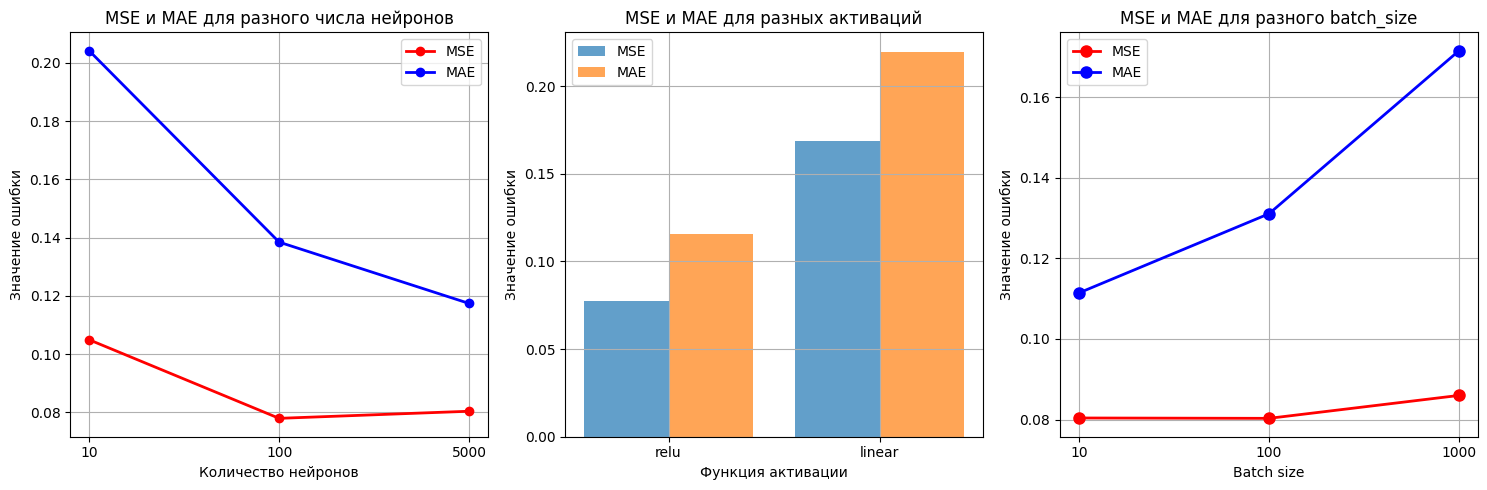

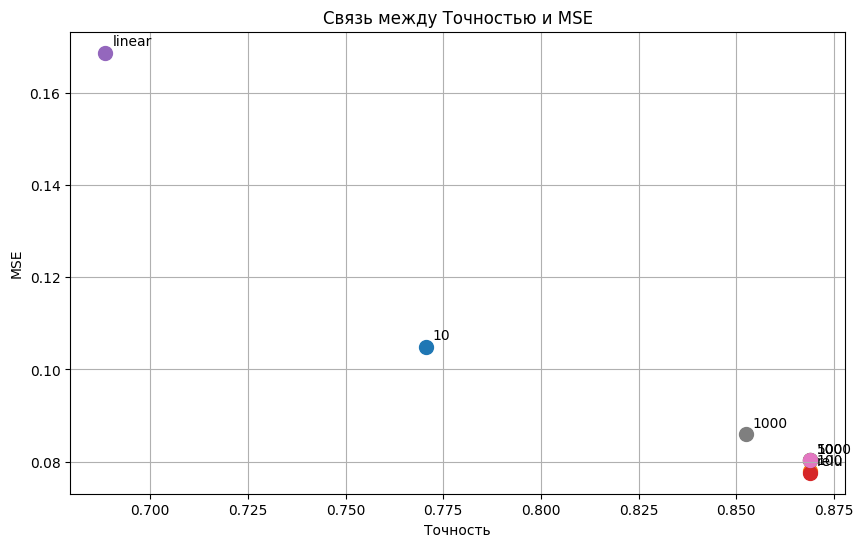

In [ ]:
# Визуализация MSE и MAE для разных моделей
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График для количества нейронов
neurons, neuron_data = zip(*neurons_results)
mse_vals = [d['mse_keras'] for d in neuron_data]
mae_vals = [d['mae_keras'] for d in neuron_data]
acc_vals = [d['accuracy'] for d in neuron_data]

x = range(len(neurons))
axes[0].plot(x, mse_vals, 'ro-', label='MSE', linewidth=2)
axes[0].plot(x, mae_vals, 'bo-', label='MAE', linewidth=2)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{n}' for n in neurons])
axes[0].set_xlabel('Количество нейронов')
axes[0].set_ylabel('Значение ошибки')
axes[0].set_title('MSE и MAE для разного числа нейронов')
axes[0].legend()
axes[0].grid(True)

# График для функций активации
acts, act_data = zip(*activation_results)
mse_vals = [d['mse_keras'] for d in act_data]
mae_vals = [d['mae_keras'] for d in act_data]

x = range(len(acts))
axes[1].bar(x, mse_vals, width=0.4, label='MSE', alpha=0.7)
axes[1].bar([i+0.4 for i in x], mae_vals, width=0.4, label='MAE', alpha=0.7)
axes[1].set_xticks([i+0.2 for i in x])
axes[1].set_xticklabels(acts)
axes[1].set_xlabel('Функция активации')
axes[1].set_ylabel('Значение ошибки')
axes[1].set_title('MSE и MAE для разных активаций')
axes[1].legend()
axes[1].grid(True)

# График для batch_size
batch, batch_data = zip(*batch_results)
mse_vals = [d['mse_keras'] for d in batch_data]
mae_vals = [d['mae_keras'] for d in batch_data]

x = range(len(batch))
axes[2].plot(x, mse_vals, 'ro-', label='MSE', linewidth=2, markersize=8)
axes[2].plot(x, mae_vals, 'bo-', label='MAE', linewidth=2, markersize=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'{b}' for b in batch])
axes[2].set_xlabel('Batch size')
axes[2].set_ylabel('Значение ошибки')
axes[2].set_title('MSE и MAE для разного batch_size')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Дополнительно: покажем связь между Accuracy и MSE
plt.figure(figsize=(10, 6))
for name, result in all_results:
    plt.scatter(result['accuracy'], result['mse_keras'], s=100, label=str(name))

plt.xlabel('Точность')
plt.ylabel('MSE')
plt.title('Связь между Точностью и MSE')
plt.grid(True)
for name, result in all_results:
    plt.annotate(str(name), (result['accuracy'], result['mse_keras']),
                xytext=(5, 5), textcoords='offset points')
plt.show()